In [4]:
from typing import Annotated

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import AnyMessage, AIMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
from typing import TypedDict
from langchain_core.messages import BaseMessage
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint

In [5]:
load_dotenv()

True

In [ ]:
# llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash",temperature=0)

# llm.invoke("Hi how are you")

Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash
Please retry in 20.608408531s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.google

ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash
Please retry in 17.893073893s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_input_token_count"
  quota_id: "GenerateContentInputTokensPerModelPerMinute-Fre

In [47]:
llm = HuggingFaceEndpoint(
    repo_id="mistralai/Mistral-7B-Instruct-v0.2",
    task="text-generation"
)

llm = ChatHuggingFace(llm=llm)

In [48]:
class ChatState(TypedDict):

    messages : Annotated[list[BaseMessage],add_messages]

In [49]:
def chat_node(state: ChatState):

    decision = interrupt({
        "type":"approval",
        "reason":"Model is about to answer a user question",
        "question": state["messages"][-1].content,
        "instructions": "Approve this question ? yes / no"
    })

    if decision["approved"] == "no":
        return {"message": [AIMessage(content="Not approved")]}
    
    else:
        response = llm.invoke(state["messages"])
        return {"messages":[response]}

In [50]:
# 3. Build the  graph 

builder = StateGraph(ChatState)

builder.add_node("chat",chat_node)

builder.add_edge(START,"chat")
builder.add_edge("chat",END)

checkpointer = MemorySaver()

app = builder.compile(checkpointer=checkpointer)

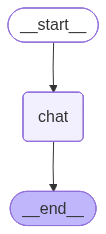

In [51]:
app

In [52]:
 # invoke 

config = {"configurable": {"thread_id":'1234'}}

initial_input = {
    "messages":[
        ("user","What is the capital of France?")
    ]
}

result = app.invoke(initial_input,config=config)

In [53]:
result

{'messages': [HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}, id='2ce73c5e-ed95-4b57-a825-f6c11248bc04')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a user question', 'question': 'What is the capital of France?', 'instructions': 'Approve this question ? yes / no'}, id='64e9673670bdc6fa888eabb22a03d069')]}

In [54]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question',
 'question': 'What is the capital of France?',
 'instructions': 'Approve this question ? yes / no'}

In [55]:
user_input = input(f"\nBackend message - {message} \n Approve the question ? yes / no :")


In [56]:
final_result = app.invoke(
    Command(resume={"approved":user_input}),
    config=config,
)

In [57]:
print(final_result)

{'messages': [HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}, id='2ce73c5e-ed95-4b57-a825-f6c11248bc04'), AIMessage(content=' The capital city of France is Paris. Paris is one of the most famous cities in the world and is known for its rich history, art, culture, and landmarks such as the Eiffel Tower, Louvre Museum, and Notre-Dame Cathedral. Paris has been the capital city of France since the late 13th century.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 72, 'prompt_tokens': 12, 'total_tokens': 84}, 'model_name': 'mistralai/Mistral-7B-Instruct-v0.2', 'system_fingerprint': '', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019b93a6-5336-7473-808c-ddca18565c95-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 72, 'total_tokens': 84})]}
